Step 1: Read in, unzip, and look at the first 5 rows of the circRNA-seq



Import Data

In [ ]:
!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133634/suppl/GSE133634%5FcircRNA%2Dexp%2Etxt%2Egz #circRNA

!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133751/suppl/GSE133751%5FmRNA%2Dexp%2Etxt%2Egz #mRNA


--2026-05-14 23:14:02--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133634/suppl/GSE133634%5FcircRNA%2Dexp%2Etxt%2Egz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.10, 130.14.250.11, 2607:f220:41e:250::13, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2380518 (2.3M) [application/x-gzip]
Saving to: ‘GSE133634_circRNA-exp.txt.gz’

GSE133634_circRNA-e 100%[===================>]   2.27M  11.7MB/s    in 0.2s    

2026-05-14 23:14:02 (11.7 MB/s) - ‘GSE133634_circRNA-exp.txt.gz’ saved [2380518/2380518]

--2026-05-14 23:14:02--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133751/suppl/GSE133751%5FmRNA%2Dexp%2Etxt%2Egz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.10, 130.14.250.11, 2607:f220:41e:250::13, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.10|:443... connected.
HTTP request sent, awaiting resp

In [ ]:
!gzip -d GSE133634_circRNA-exp.txt.gz


gzip: GSE133634_circRNA-exp.txt already exists; do you wish to overwrite (y or n)? n
	not overwritten


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("GSE133634_circRNA-exp.txt", sep="\t")

df = df.set_index("circleName")

df.head()

,chr,start,end,strand,circleType,circBase,gene symbol,con-3-circle_count,con-4-circle_count,con-5-circle_count,...,HV-2-circle_RPM,HV-4-circle_RPM,HV-6-circle_RPM,con-3-circle_junction,con-4-circle_junction,con-5-circle_junction,HV-2-circle_junction,HV-4-circle_junction,HV-6-circle_junction,Web
circleName,,,,,,,,,,,,,,,,,,,,,
hsa_circ:chr4:140432791-140439109,chr4,140432791,140439109,-,exonpos,NONE,SETD7,8,4,3,...,0.026590,0.176057,0.075461,0,0,0,0,0,2,NONE
hsa_circ:chr16:51189072-51189509,chr16,51189072,51189509,-,intergenic,NONE,*,8,0,0,...,0.000000,0.000000,0.000000,2,0,0,0,0,0,NONE
hsa_circ:chr18:9195549-9211782,chr18,9195549,9211782,+,exonpos,NONE,ANKRD12,0,2,0,...,0.013295,0.000000,0.012577,0,2,0,1,0,1,NONE
hsa_circ:chr3:49348053-49349087,chr3,49348053,49349087,-,exonpos,NONE,USP4,0,3,12,...,0.053181,0.075453,0.050307,0,3,12,4,6,4,NONE
hsa_circ:chr1:1735858-1747301,chr1,1735858,1747301,-,exonpos,hsa_circ_0009352,GNB1,1,0,1,...,0.000000,0.025151,0.050307,1,0,1,0,2,4,http://www.circbase.org/cgi-bin/singlerecord.c...


In [ ]:
df.shape

(51368, 26)

Learn about the variables included

In [ ]:
print(df.columns)

Index(['chr', 'start', 'end', 'strand', 'circleType', 'circBase',
       'gene symbol', 'con-3-circle_count', 'con-4-circle_count',
       'con-5-circle_count', 'HV-2-circle_count', 'HV-4-circle_count',
       'HV-6-circle_count', 'con-3-circle_RPM', 'con-4-circle_RPM',
       'con-5-circle_RPM', 'HV-2-circle_RPM', 'HV-4-circle_RPM',
       'HV-6-circle_RPM', 'con-3-circle_junction', 'con-4-circle_junction',
       'con-5-circle_junction', 'HV-2-circle_junction', 'HV-4-circle_junction',
       'HV-6-circle_junction', 'Web'],
      dtype='object')


Although the authors include the RPM normalized values, we want to go through the process of normalizing ourselves. So we will first subset just the _count columns of the df

In [ ]:
circ_count_cols = [
    'con-3-circle_count',
    'con-4-circle_count',
    'con-5-circle_count',
    'HV-2-circle_count',
    'HV-4-circle_count',
    'HV-6-circle_count'
]

circ_RNA_raw = df[circ_count_cols] #Now we've subsetted just the 3 control count columns and the 3 HV count columns.

circ_RNA_raw.head()

,con-3-circle_count,con-4-circle_count,con-5-circle_count,HV-2-circle_count,HV-4-circle_count,HV-6-circle_count
circleName,,,,,,
hsa_circ:chr4:140432791-140439109,8,4,3,2,14,6
hsa_circ:chr16:51189072-51189509,8,0,0,0,0,0
hsa_circ:chr18:9195549-9211782,0,2,0,1,0,1
hsa_circ:chr3:49348053-49349087,0,3,12,4,6,4
hsa_circ:chr1:1735858-1747301,1,0,1,0,2,4


Step 2: Perform RPM normalization

In [ ]:
circ_RNA_RPM = circ_RNA_raw.div(circ_RNA_raw.sum(axis=0), axis=1) * 1e6
circ_RNA_RPM.head()

,con-3-circle_count,con-4-circle_count,con-5-circle_count,HV-2-circle_count,HV-4-circle_count,HV-6-circle_count
circleName,,,,,,
hsa_circ:chr4:140432791-140439109,4.879644,2.268734,2.012716,1.414889,7.970391,3.522601
hsa_circ:chr16:51189072-51189509,4.879644,0.000000,0.000000,0.000000,0.000000,0.000000
hsa_circ:chr18:9195549-9211782,0.000000,1.134367,0.000000,0.707445,0.000000,0.587100
hsa_circ:chr3:49348053-49349087,0.000000,1.701550,8.050865,2.829779,3.415882,2.348400
hsa_circ:chr1:1735858-1747301,0.609955,0.000000,0.670905,0.000000,1.138627,2.348400


Step 3: Apply log transformation to RPM values

In [ ]:
circ_RNA_log_transformed = np.log2(circ_RNA_RPM+ 1)
circ_RNA_log_transformed.head()

,con-3-circle_count,con-4-circle_count,con-5-circle_count,HV-2-circle_count,HV-4-circle_count,HV-6-circle_count
circleName,,,,,,
hsa_circ:chr4:140432791-140439109,2.555729,1.708732,1.591065,1.271957,3.165171,2.177153
hsa_circ:chr16:51189072-51189509,2.555729,0.000000,0.000000,0.000000,0.000000,0.000000
hsa_circ:chr18:9195549-9211782,0.000000,1.093808,0.000000,0.771839,0.000000,0.666393
hsa_circ:chr3:49348053-49349087,0.000000,1.433788,3.178056,1.937261,2.142702,1.743472
hsa_circ:chr1:1735858-1747301,0.687021,0.000000,0.740630,0.000000,1.096685,1.743472


In [ ]:
#Subset just the control samples
control_cols_log_transformed  = circ_RNA_log_transformed[['con-3-circle_count', 'con-4-circle_count', 'con-5-circle_count']]
control_cols_log_transformed.head()

,con-3-circle_count,con-4-circle_count,con-5-circle_count
circleName,,,
hsa_circ:chr4:140432791-140439109,2.555729,1.708732,1.591065
hsa_circ:chr16:51189072-51189509,2.555729,0.000000,0.000000
hsa_circ:chr18:9195549-9211782,0.000000,1.093808,0.000000
hsa_circ:chr3:49348053-49349087,0.000000,1.433788,3.178056
hsa_circ:chr1:1735858-1747301,0.687021,0.000000,0.740630


In [ ]:
#Subset just the infected samples
HV_cols_log_transformed  = circ_RNA_log_transformed[['HV-2-circle_count', 'HV-4-circle_count', 'HV-6-circle_count']]
HV_cols_log_transformed.head()

,HV-2-circle_count,HV-4-circle_count,HV-6-circle_count
circleName,,,
hsa_circ:chr4:140432791-140439109,1.271957,3.165171,2.177153
hsa_circ:chr16:51189072-51189509,0.000000,0.000000,0.000000
hsa_circ:chr18:9195549-9211782,0.771839,0.000000,0.666393
hsa_circ:chr3:49348053-49349087,1.937261,2.142702,1.743472
hsa_circ:chr1:1735858-1747301,0.000000,1.096685,1.743472


Calculate means and subtract

In [ ]:
results = pd.DataFrame(index=circ_RNA_log_transformed.index)
results['mean_control']  = control_cols_log_transformed.mean(axis=1)
results['mean_HV'] = HV_cols_log_transformed.mean(axis=1)
results['log2FC']        = results['mean_HV'] - results['mean_control']

results.head()


,mean_control,mean_HV,log2FC
circleName,,,
hsa_circ:chr4:140432791-140439109,1.951842,2.204760,0.252918
hsa_circ:chr16:51189072-51189509,0.851910,0.000000,-0.851910
hsa_circ:chr18:9195549-9211782,0.364603,0.479411,0.114808
hsa_circ:chr3:49348053-49349087,1.537281,1.941145,0.403864
hsa_circ:chr1:1735858-1747301,0.475884,0.946719,0.470835


T-test

In [ ]:
t_stats, p_vals = stats.ttest_ind(
    HV_cols_log_transformed,
    control_cols_log_transformed.values,
    axis=1,
    equal_var=True
)

results['t_stat'] = t_stats
results['pvalue'] = p_vals

results.head()


,mean_control,mean_HV,log2FC,t_stat,pvalue
circleName,,,,,
hsa_circ:chr4:140432791-140439109,1.951842,2.204760,0.252918,0.404371,0.706629
hsa_circ:chr16:51189072-51189509,0.851910,0.000000,-0.851910,-1.000000,0.373901
hsa_circ:chr18:9195549-9211782,0.364603,0.479411,0.114808,0.262477,0.805918
hsa_circ:chr3:49348053-49349087,1.537281,1.941145,0.403864,0.436098,0.685270
hsa_circ:chr1:1735858-1747301,0.475884,0.946719,0.470835,0.837862,0.449253


FDR Calculation

Claude Prompt: Using the Benjimini-Hochberg procedure, compute the FDRs from comparing genes belonging to the mean_control group versus the mean_HV group. Append the results to a data frame called "results".

In [ ]:
pvs   = results['pvalue'].values
logFC = results['log2FC'].values

# Check how many NaNs
print("Total number of missing values from t tests:", np.isnan(pvs).sum())

# Filter out NaNs
pvs_valid   = pvs[~np.isnan(pvs)]
logFC_valid = logFC[~np.isnan(pvs)]
genes_valid = circ_RNA_log_transformed.index[~np.isnan(pvs)]

Total number of missing values from t tests: 0


In [ ]:
# Get FDRs for the valid p-values
fdrs_valid = stats.false_discovery_control(pvs_valid, method='bh')

In [ ]:
valid_mask = results['pvalue'].notna()
results['padj'] = np.nan
results.loc[valid_mask, 'padj'] = fdrs_valid

results.head()

,mean_control,mean_HV,log2FC,t_stat,pvalue,padj
circleName,,,,,,
hsa_circ:chr4:140432791-140439109,1.951842,2.204760,0.252918,0.404371,0.706629,0.907233
hsa_circ:chr16:51189072-51189509,0.851910,0.000000,-0.851910,-1.000000,0.373901,0.654664
hsa_circ:chr18:9195549-9211782,0.364603,0.479411,0.114808,0.262477,0.805918,0.943792
hsa_circ:chr3:49348053-49349087,1.537281,1.941145,0.403864,0.436098,0.685270,0.897935
hsa_circ:chr1:1735858-1747301,0.475884,0.946719,0.470835,0.837862,0.449253,0.729885


Sort for the differentially expressed circRNAs based on the author's criteria: |Log2FC| > 1, FDR < 0.05

In [ ]:
sig = results[(results['padj'] < 0.05) & (results['log2FC'].abs() > 1)]

sig.shape

#We get 10 DEGs, but in the paper, the authors identified 70 circRNA DEGs. Likely because they used edgeR...
#So we can try doing this again using PyDESeq2.


(10, 6)

Trying the analysis again with PyDeSEQ2:

LLM prompt: using Deseq2 in python, perform a DEG analysis comparing control groups (con3, con4, and con5) versus infected groups (HV2, HV4, HV6). Obtain the log2FC, the FDRs, and filter based on |log2FC| > 1 and FDR < 0.05.

In [ ]:
!pip install pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd

# PyDESeq2 needs RAW counts (integers), not log-transformed RPM
counts = circ_RNA_RPM[['con-3-circle_count', 'con-4-circle_count', 'con-5-circle_count',
                        'HV-2-circle_count', 'HV-4-circle_count', 'HV-6-circle_count']].T

counts = counts.astype(int)

# Metadata dataframe
metadata = pd.DataFrame({
    'condition': ['control', 'control', 'control', 'infected', 'infected', 'infected']
}, index=counts.index)

# Run DESeq2
dds = DeseqDataSet(counts=counts, metadata=metadata, design_factors="condition")
dds.deseq2()

# Extract results
stat_res = DeseqStats(dds, contrast=["condition", "infected", "control"])
stat_res.summary()

results_deseq = stat_res.results_df
sig = results_deseq[(results_deseq['padj'] < 0.05) & (results_deseq['log2FoldChange'].abs() > 1)]
print(f"Significant DEGs: {len(sig)}")

sig.head()

/tmp/ipykernel_12967/822001209.py:18: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=counts, metadata=metadata, design_factors="condition")
Fitting size factors...
... done in 0.05 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 46.53 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 2.08 seconds.

Fitting MAP dispersions...
... done in 61.18 seconds.

Fitting LFCs...
... done in 42.53 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 13.92 seconds.



Log2 fold change & Wald test p-value: condition infected vs control
                                       baseMean  log2FoldChange     lfcSE  \
circleName                                                                  
hsa_circ:chr4:140432791-140439109      3.104540        0.442554  1.059699   
hsa_circ:chr16:51189072-51189509       0.638895       -2.872309  4.264178   
hsa_circ:chr18:9195549-9211782         0.169456       -1.013776  4.425591   
hsa_circ:chr3:49348053-49349087        2.596992       -0.407152  1.478564   
hsa_circ:chr1:1735858-1747301          0.493865        2.435615  3.191354   
...                                         ...             ...       ...   
hsa_circ:chr14:67147825-67155104      19.802930       -0.147805  0.756584   
hsa_circ:chr10:70731647-70737444       0.000000             NaN       NaN   
hsa_circ:chr6:26204875-26205001    10059.577848       -1.414189  0.514747   
hsa_circ:chr16:80364674-80364827       1.606480       -0.056629  1.142025   
hsa_circ

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
circleName,,,,,,
hsa_circ:chr20:35563432-35575207,12.974731,3.882704,0.846170,4.588560,4.463130e-06,1.238749e-03
hsa_circ:chr20:62203461-62204574,773.590885,4.154533,0.453001,9.171144,4.680260e-20,1.883570e-16
hsa_circ:chr1:27994737-27995857,1844.622057,7.000084,0.703374,9.952153,2.467853e-23,3.972750e-19
hsa_circ:chr1:154556203-154556453,14.947969,2.120936,0.584492,3.628683,2.848709e-04,4.727682e-02
hsa_circ:chr11:60706952-60707110,52.876592,4.472097,0.825664,5.416366,6.082253e-08,2.646273e-05


In [ ]:
sig.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
circleName,,,,,,
hsa_circ:chr20:35563432-35575207,12.974731,3.882704,0.846170,4.588560,4.463130e-06,1.238749e-03
hsa_circ:chr20:62203461-62204574,773.590885,4.154533,0.453001,9.171144,4.680260e-20,1.883570e-16
hsa_circ:chr1:27994737-27995857,1844.622057,7.000084,0.703374,9.952153,2.467853e-23,3.972750e-19
hsa_circ:chr1:154556203-154556453,14.947969,2.120936,0.584492,3.628683,2.848709e-04,4.727682e-02
hsa_circ:chr11:60706952-60707110,52.876592,4.472097,0.825664,5.416366,6.082253e-08,2.646273e-05


In [ ]:
sig.shape #Gives us 97 DEGs which is a lot closer to the 70 DEGs that the authors identified...

(97, 6)

Make volcano

In [ ]:
pvs   = results_deseq['pvalue'].values
logFC = results_deseq['log2FoldChange'].values

print("Total missing p-values:", np.isnan(pvs).sum())

Total missing p-values: 6820


Remove those 0/NA p-values

In [ ]:
valid  = ~np.isnan(pvs)
pvs_valid   = pvs[valid]
logFC_valid = logFC[valid]

In [ ]:
fdrs_valid = results_deseq['padj'].values[valid]

# P-value cutoff at FDR=0.05
p_fdr005     = pvs_valid[fdrs_valid < 0.05].max()
p_cutoff     = p_fdr005
logFC_cutoff = 1
print("P-value at FDR=0.05:", p_fdr005)

P-value at FDR=0.05: 0.0003036052002981498


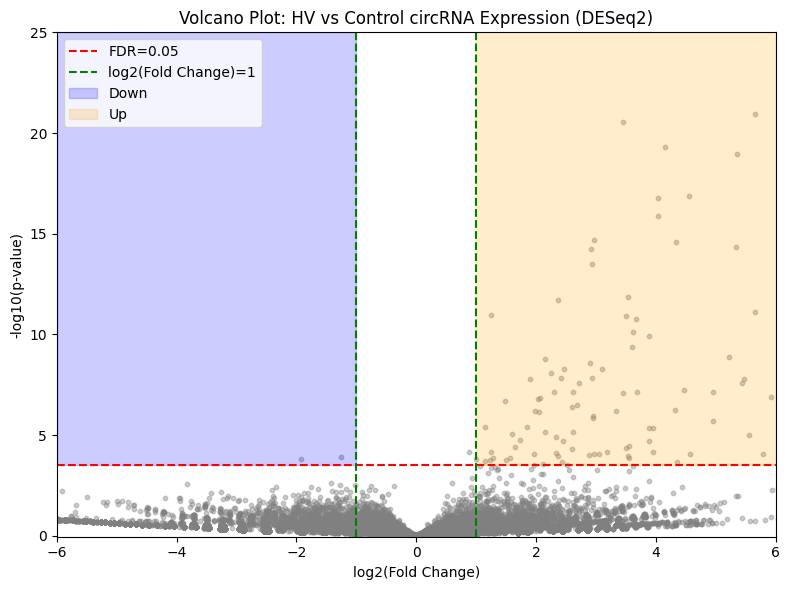

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(logFC_valid, -np.log10(pvs_valid), alpha=0.4, c='grey', s=10)
plt.xlabel('log2(Fold Change)')
plt.ylabel('-log10(p-value)')
plt.axhline(-np.log10(p_cutoff), color='r', linestyle='--', label='FDR=0.05')
plt.axvline( logFC_cutoff,       color='g', linestyle='--', label='log2(Fold Change)=1')
plt.axvline(-logFC_cutoff,       color='g', linestyle='--')
plt.fill_between([-6, -1], [-np.log10(p_cutoff), -np.log10(p_cutoff)], [25, 25], alpha=0.2, color='blue',   label='Down')
plt.fill_between([ 1,  6], [-np.log10(p_cutoff), -np.log10(p_cutoff)], [25, 25], alpha=0.2, color='orange', label='Up')
plt.xlim(-6, 6)
plt.ylim(-0.05, 25)
plt.legend()
plt.title('Volcano Plot: HV vs Control circRNA Expression (DESeq2)')
plt.tight_layout()
plt.show()



In [ ]:
#LLM prompt: tell me the names of the DEGs, and then tell me the names of the upregulated and downregulated ones
print(f"Total significant circRNAs: {len(sig)}")
print(f"Upregulated   (log2FC >  1): {len(sig[sig['log2FoldChange'] >  1])}")
print(f"Downregulated (log2FC < -1): {len(sig[sig['log2FoldChange'] < -1])}")

#Pretty good, the authors identified 70 DEGs, 65 up and 5 down so this is somewhat consistent. Only difference is we used pydeseq2 and they used edgeR.

Total significant circRNAs: 97
Upregulated   (log2FC >  1): 95
Downregulated (log2FC < -1): 2


Part 2: TF
 Analysis (adapted from Dr. Hong's code)

In [ ]:
!pip install gseapy -q

import pandas as pd
import gseapy as gp
from gseapy import barplot, dotplot
import matplotlib.pyplot as plt

In [ ]:
id_to_gene = df['gene symbol'].to_dict()

deg_symbols_circ = [id_to_gene[g] for g in sig.index if g in id_to_gene]
deg_symbols_circ = [s for s in deg_symbols_circ if pd.notna(s)]

print(f"Converted: {len(deg_symbols_circ)} genes")
print(deg_symbols_circ[:10])

Converted: 97 genes
['SAMHD1', 'HELZ2', 'IFI6', 'ADAR', 'SLC15A3', 'OAS3', 'IFI44L', 'C19orf66', 'RNF213', 'HELZ2']


In [ ]:
tf_results_circ = gp.enrichr(
    gene_list=deg_symbols_circ,
    gene_sets=[
        'ChEA_2022',
        'ENCODE_TF_ChIP-seq_2015',
        'TF_Perturbations_Followed_by_Expression'
    ],
    organism='human',
    outdir=None
)

/tmp/ipykernel_12967/3055629300.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


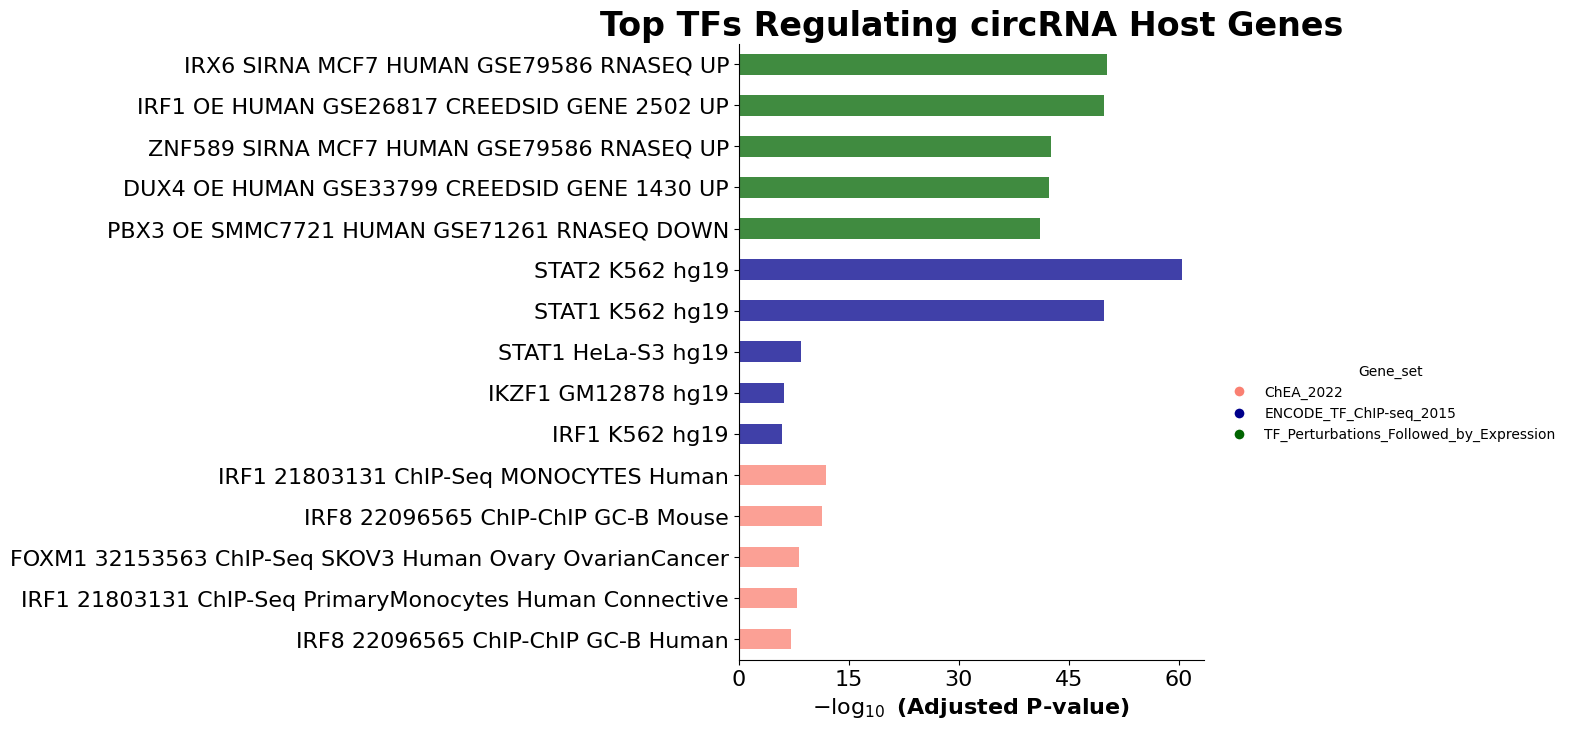

In [ ]:
ax = barplot(
    tf_results_circ.results,
    column='Adjusted P-value',
    group='Gene_set',
    title='Top TFs Regulating circRNA Host Genes',
    size=10,
    top_term=5,
    figsize=(6, 8),
    color={
        'ChEA_2022': 'salmon',
        'ENCODE_TF_ChIP-seq_2015': 'darkblue',
        'TF_Perturbations_Followed_by_Expression': 'darkgreen'
    }
)
plt.tight_layout()
plt.show()


Final step: Go term on common circRNA and mRNA degs

/tmp/ipykernel_12967/3828118528.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


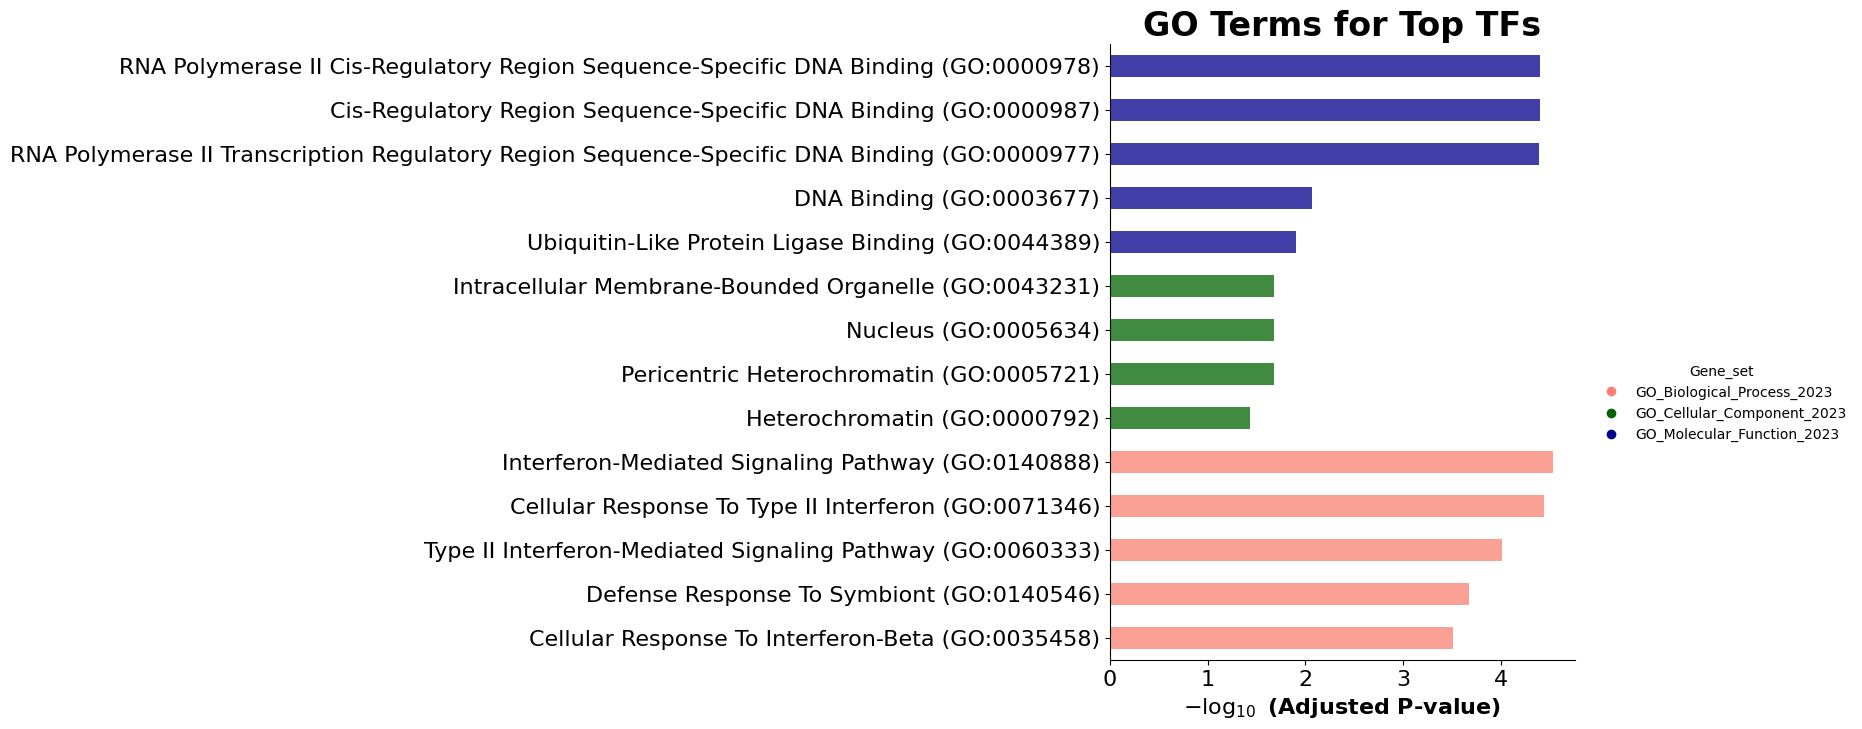

In [ ]:
import gseapy as gp
from gseapy import barplot, dotplot
import matplotlib.pyplot as plt

# TF list
tf_list = ['IRF1', 'DUX4', 'STAT1', 'STAT2', 'IKZF1', 'IRF8']

# Run GO enrichment
go_results = gp.enrichr(
    gene_list=tf_list,
    gene_sets=[
        'GO_Biological_Process_2023',
        'GO_Molecular_Function_2023',
        'GO_Cellular_Component_2023'
    ],
    organism='human',
    outdir=None
)

go_results.results.head(5)

# Barplot
ax = barplot(
    go_results.results,
    column='Adjusted P-value',
    group='Gene_set',
    title='GO Terms for Top TFs',
    size=10,
    top_term=5,
    figsize=(6, 8),
    color={
        'GO_Biological_Process_2023': 'salmon',
        'GO_Molecular_Function_2023': 'darkblue',
        'GO_Cellular_Component_2023': 'darkgreen'
    }
)
plt.tight_layout()
plt.show()


PPI Network from TF DEGs upstream of circRNAs, mRNAs and TF DEGs downstream of miRNAs.

In [ ]:
#LLM Prompt: write me code in Python that takes the Enrichr data as the input and outputs me a list of the 10 TFs arranged from lowest adj. P value to highest.


# Combine all TF enrichment results and pull the top 10 unique TFs
# ranked by adjusted p-value across all datasets

import pandas as pd

# Copy results dataframe
df = tf_results_circ.results.copy()

# Sort by adjusted p-value (smallest = most significant)
df = df.sort_values("Adjusted P-value")

# Extract TF name from the 'Term' column
# (usually formatted like "STAT1 human ChIP-seq ...")
df["TF"] = df["Term"].str.split().str[0]

# Keep the best (lowest p-value) entry per TF
top_tfs = (
    df.groupby("TF", as_index=False)
      .first()
      .sort_values("Adjusted P-value")
)

# Display relevant columns
top_tfs = top_tfs[
    ["TF", "Gene_set", "Adjusted P-value", "Overlap", "Combined Score"]
]

print(top_tfs)

             TF                                 Gene_set  Adjusted P-value  \
468       STAT2                  ENCODE_TF_ChIP-seq_2015      4.496487e-61   
215        IRX6  TF_Perturbations_Followed_by_Expression      6.060465e-51   
206        IRF1  TF_Perturbations_Followed_by_Expression      1.818585e-50   
467       STAT1                  ENCODE_TF_ChIP-seq_2015      1.819032e-50   
571      ZNF589  TF_Perturbations_Followed_by_Expression      3.231050e-43   
..          ...                                      ...               ...   
62       CREBBP                  ENCODE_TF_ChIP-seq_2015      9.996178e-01   
52        CEBPZ                  ENCODE_TF_ChIP-seq_2015      9.996178e-01   
109        ELK4                  ENCODE_TF_ChIP-seq_2015      9.996178e-01   
69        CTCFL                  ENCODE_TF_ChIP-seq_2015      9.996178e-01   
582  eGFP-NR4A1                  ENCODE_TF_ChIP-seq_2015      9.996178e-01   

    Overlap  Combined Score  
468  41/271    28424.600911  
215

Get a list of the Top circRNA DEG upstream TFs, create venn diagram


In [ ]:
DEG_TFs_circRNA = top_tfs["TF"].tolist()

print(DEG_TFs_circRNA)

#Now we have the list of all the TFs for the circRNA DEGs. Next, I will go back to my mRNA dataset and run the same code there. Then we will put it all in STRING to make a PPI network.

['STAT2', 'IRX6', 'IRF1', 'STAT1', 'ZNF589', 'DUX4', 'TP63', 'PBX3', 'NCOA1', 'REST', 'PRRX1', 'LIN28', 'SPDEF', 'KLF9', 'MAF', 'ZNF142', 'IRF9', 'HOXA11', 'SETDB1', 'MYB', 'TWIST1', 'KMT2A', 'POU1F1', 'CTCF', 'PAX5', 'ZEB1', 'JUN', 'ZMAT4', 'ZNF253', 'TBX3', 'NR2C2', 'OVOL2', 'NR5A2', 'NME2', 'EGR3', 'RARA', 'SOX2', 'SP140', 'GATA4', 'FOXM1', 'NFIX', 'FOXQ1', 'IRF8', 'ZBTB7A', 'IRF4', 'ERG', 'ADAR', 'HES1', 'MECOM', 'FOSL1', 'NFE2L2', 'FOXL2', 'IRF7', 'IKZF1', 'PPARG', 'ATF3', 'IKZF4', 'HSF1', 'KCNIP3', 'ZNF581', 'HMGA2', 'TSHZ3', 'RELA', 'FOXP3', 'E2F2', 'MYC', 'FOXD3', 'FOXF2', 'ESRRA', 'KLF2', 'FOXD4L6', 'ZHX2', 'POU5F1', 'STAT3', 'EP300', 'IKZF3', 'NR1I3', 'AIRE', 'ESR1', 'DNMT1', 'TFAP2C', 'EBF1', 'GLIS2', 'JUNB', 'CEBPA', 'PPARA', 'GFI1', 'SPI1', 'GATA3', 'ADARB1', 'TP53', 'HIF1A', 'SRF', 'POU2AF1', 'EHF', 'POLR2A', 'ETS1', 'NFYA', 'ARNTL2', 'PRDM1', 'VDR', 'DMRTA2', 'SP3', 'RUNX1', 'CLOCK', 'MITF', 'SREBF2', 'XBP1', 'USF1', 'FOXO1', 'PCGF2', 'ZXDC', 'TCF12', 'GRHL2', 'HOXA9', '

In [ ]:
len(DEG_TFs_circRNA)

583

In [ ]:
#I'm just going to redefine the DEG_TFs_mRNA that I got from my other notebook

DEG_TFs_mRNA = ['IRF1', 'NCOA1', 'STAT2', 'TP63', 'DUX4', 'STAT1', 'IRX6', 'REST', 'MYB', 'PBX3', 'SPDEF', 'ZNF589', 'KLF9', 'POU1F1', 'MAF', 'IRF9', 'EGR3', 'TWIST1', 'ZEB1', 'IRF4', 'KMT2A', 'PRRX1', 'PAX5', 'LIN28', 'ZNF142', 'HES1', 'NME2', 'SP140', 'FOXM1', 'IRF8', 'HOXA11', 'PPARG', 'SETDB1', 'NR2C2', 'CTCF', 'RARA', 'TBX3', 'SOX2', 'NFE2L2', 'HSF1', 'ZMAT4', 'FOSL1', 'ZBTB7A', 'SRF', 'FOXQ1', 'OVOL2', 'HMGA2', 'VDR', 'JUN', 'NR5A2', 'ZNF253', 'RELA', 'NFIX', 'KCNIP3', 'NEUROG1', 'MYC', 'IKZF4', 'TFAP2C', 'AIRE', 'IKZF3', 'IKZF1', 'E2F2', 'TP53', 'IRF7', 'ATF6B', 'IRF5', 'GTF2I', 'POU5F1', 'BATF', 'GATA4', 'ATF3', 'STAT4', 'ERG', 'FOXD4L6', 'ADAR', 'NCOA2', 'PRDM1', 'NR3C1', 'WT1', 'GLIS2', 'STAT3', 'KLF2', 'ZHX2', 'FLI1', 'FOXD3', 'TCF3', 'KDM2B', 'ESRRA', 'EP300', 'FOXP3', 'TWIST2', 'BACH1', 'ARID3A', 'MECOM', 'DNMT1', 'PPARA', 'NFKB2', 'FOXP1', 'CEBPA', 'USF1', 'FOXA2', 'AR', 'NFE2L1', 'BCL6', 'ETS1', 'MECP2', 'GLI1', 'TSHZ3', 'PPARD', 'RXRA', 'NCOR', 'DOT1L', 'POU2AF1', 'ESR1', 'TCF4', 'FOXO1', 'HIF1A', 'CLOCK', 'GFI1B', 'JUND', 'ZBTB7B', 'E2F8', 'FOXL2', 'SP3', 'GATA1', 'SPI1', 'E2F6', 'PCGF2', 'GATA3', 'NCOA3', 'ZXDC', 'TCF7', 'MITF', 'NR1I3', 'ZRSR2', 'BNC2', 'NFKB1', 'DLX5', 'FOXA1', 'ELF3', 'GRHL2', 'IRF3', 'EZH1', 'XBP1', 'EHF', 'ELF4', 'HOXA9', 'CEBPG', 'NANOG', 'OVOL1', 'SMRT', 'SOX7', 'KLF15', 'SOX4', 'KLF5', 'PAX7', 'YBX1', 'TET1', 'ZFX', 'NFYC', 'CUX1', 'ZBTB38', 'ADARB1', 'GFI1', 'SMAD', 'GTF2B', 'ZEB2', 'FOXF2', 'SREBF2', 'SOX9', 'NRF1', 'STAT5', 'TCF21', 'EGR2', 'FOXP2', 'ARX', 'CEBPB', 'U2AF1', 'POU2F1', 'RELB', 'EPAS1', 'E2F1', 'RUNX1', 'KLF1', 'RORC', 'ZNF207', 'PRDM16', 'GATA6', 'STAT6', 'BCL11A', 'ZNF581', 'HOXA7', 'ZNF395', 'PGR', 'PDX1', 'HNF1A', 'SUZ12', 'AHR', 'NEUROD1', 'STAT5A', 'LHX1', 'ZNF658', 'RC3H1', 'GATA2', 'PCGF6', 'BACH2', 'CDX2', 'NR1H3', 'THRA', 'KLF6', 'KLF3', 'KLF13', 'EZH2', 'VAX2', 'CREB1', 'ZBTB48', 'ARNTL', 'MAFK', 'SOX17', 'SMAD1', 'TAL1', 'NEUROG3', 'NKX25', 'MBD2', 'SA1', 'MYCN', 'YY1', 'ZNF503', 'NR4A2', 'HNF4A', 'MBNL1', 'ETS2', 'ZNF217', 'PHF20', 'NFYA', 'SON', 'ARNTL2', 'ASCL1', 'DDIT3', 'KLF10', 'ARID3B', 'TFEB', 'EGR1', 'KLF4', 'ONECUT2', 'XPA', 'PRDM14', 'ADNP', 'DMRTA2', 'JUNB', 'MTF2', 'E2F3', 'GATA5', 'BHLHA15', 'ARID2', 'RXR', 'P300', 'TCF12', 'TET2', 'OCT4', 'PBRM1', 'ZFP42', 'EBF1', 'KLF7', 'HEY2', 'INSM1', 'PLAGL2', 'SNAI1', 'POU4F1', 'YY2', 'IRF6', 'RORA', 'RBM10', 'SATB1', 'ETV2', 'IRX5', 'PAX3', 'THRB', 'ZNF148', 'NR2F2', 'STAT5B', 'SATB2', 'DEAF1', 'ZIC3', 'DMRT1', 'SOX11', 'OTX2', 'BPTF', 'SALL4', 'AFF4', 'ATF6', 'YEATS2', 'ATF4', 'NR1I2', 'EP400', 'LMO2', 'LIN28A', 'HNF4G', 'TRIM28', 'EOMES', 'P63', 'TRPS1', 'NUCKS1', 'PITX2', 'CEBPD', 'FOXO3', 'MEIS2', 'RUNX2', 'RARB', 'ZNF143', 'DLX4', 'TOX4', 'PAX2', 'TET3', 'SRY', 'UTX', 'ENL', 'PU', 'ZNF750', 'MBD3', 'NACC1', 'HMX1', 'ELK3', 'NFYB', 'BRD4', 'SMAD4', 'AF4', 'HOXA10', 'BMI1', 'EGR4', 'CBX2', 'POU3F3', 'TFE3', 'LXR', 'UBF1/2', 'CHD1', 'NFIC', 'PPAR', 'SMAD3', 'RACK7', 'LEF1', 'ETV1', 'KAP1', 'PCGF4', 'RBPJ', 'SP1', 'SMAD2/3', 'NRF2', 'MYOD1', 'NFE2', 'TBP', 'MSGN1', 'EBF3', 'GTF3C2', 'AFF1', 'TCF7L2', 'NRL', 'BNC1', 'AUTS2', 'PAX6', 'ESRRB', 'HNF1B', 'EBNA1', 'TCF3/E2A', 'LYL1', 'EVI1', 'ELK1', 'SMAD2', 'PAX3-FKHR', 'CJUN', 'ESR2', 'PHF8', 'HNFA', 'SCL', 'Nerf2', 'ATF2', 'FOS', 'NFXL1', 'SOX5', 'NFATC3', 'ESRRG', 'MEF2A', 'ONECUT1', 'TCF12/HEB', 'GF1', 'NFI', 'MEF2D', 'RAG1', 'RUNX', 'BCL11B', 'NFIA', 'RAD21', 'KDM1A', 'SOX3', 'NR2E3', 'SMC1', 'PBX1', 'OCT1', 'ZFP281', 'HOXC13', 'E2A', 'ZFPM2', 'EED', 'HIVEP2', 'E2F4', 'MYRF', 'WDR5', 'JARID1B-DAIN', 'PIN1', 'CSB', 'RCOR1', 'NELFE', 'BCL3', 'KAT2A', 'POLR2A', 'SMC3', 'CMYC', 'CHD7', 'HOXB4', 'ZBTB20', 'EMX2', 'PU.1', 'CDH4', 'MYBL1', 'P68', 'DPY', 'RNF2', 'FOXH1', 'TAF2', 'PBX', 'CREM', 'LMX1B', 'CIITA', 'SOX10', 'CNOT3', 'NMYC', 'HAND2', 'XRN2', 'SMARCD1', 'TBX20', 'JARID2', 'NOTCH1', 'ZNF263', 'TBX5', 'MEIS1', 'FUS', 'ARID1A', 'ASXL1', 'P53', 'YAP1', 'NKX2-5', 'ESET', 'TDRD3', 'ASH2L', 'NR0B1', 'LDB1', 'TAF7L', 'CTBP1', 'CTNNB1', 'SALL1', 'TCFCP2L1', 'CTBP2', 'TAF15', 'TOP2B', 'MAFF', 'GTF2F1', 'CBP', 'PHC1', 'SIN3A', 'SREBP2', 'POU3F2', 'ELF1', 'ERA', 'BCAT', 'SOX6', 'EWS', 'PU1', 'SMARCA4', 'ISL1', 'ZZZ3', 'MYBL2', 'TFAP2A', 'SREBP1', 'CRX', 'RFX5', 'DNAJC2', 'ILF3', 'PRDM5', 'BCOR', 'GF1B', 'PITX1', 'TBL1', 'EKLF', 'PIAS1', 'CCND1', 'USF2', 'ZC3H11A', 'HOXB13', 'HTT', 'GABPA', 'HES6', 'TTF2', 'GBX2', 'HOXB7', 'PHOX2B', 'ZFP57', 'HOXC9', 'SMC4', 'RCOR3', 'RAC3', 'HOXD13', 'EBNA2', 'SFPI1', 'EWS-FLI1', 'MBD1', 'FOXI1', 'LUZP1', 'RCOR2', 'OLIG2', 'TCFAP2C', 'IGF1R', 'RING1B', 'NCOR1', 'NFIB', 'ZNF652', 'MNX1', 'RARG', 'CDKN2AIP', 'PADI4', 'TRP63', 'POLR3A', 'TEAD4', 'DACH1', 'PKCTHETA', 'ELK4', 'NEUROD2', 'POU3F1', 'ARNT', 'CHD4', 'ELF5', 'TBX2', 'NR3C2', 'NELFA', 'GABP', 'SIN3B', 'ZBTB16', 'HCFC1', 'KDM5B', 'JARID1A', 'KDM5A', 'ER', 'TBX4', 'DCP1A', 'DROSHA', 'THAP11', 'EST1', 'EWS-ERG', 'ZNF274', 'eGFP-NR4A1', 'eGFP-JUND', 'eGFP-JUNB', 'eGFP-HDAC8', 'eGFP-GATA2', 'eGFP-FOS', 'ATF1', 'TBL1XR1', 'TAF7', 'THAP1', 'TAF1', 'SUPT20H', 'SREBF1', 'SP4', 'SP2', 'SMARCC2', 'SMARCC1', 'SMARCB1', 'SIX5', 'SIRT6', 'SAP30', 'RUNX3', 'RBBP5', 'WRNIP1', 'WHSC1', 'UBTF', 'POU2F2', 'POLR2AphosphoS5', 'POLR2AphosphoS2', 'PML', 'NFATC1', 'MYOG', 'MXI1', 'MTA3', 'MBD4', 'MAZ', 'MAX', 'KDM4A', 'KAT2B', 'ZBTB33', 'HMGN3', 'HDAC6', 'HDAC2', 'HDAC1', 'HA-E2F1', 'FOSL2', 'CTCFL', 'CREBBP', 'CHD2', 'CEBPZ', 'CCNT2', 'CBX8', 'CBX3', 'BRCA1', 'ZNF384', 'ZMIZ1', 'ZKSCAN1', 'BHLHE40', 'BCLAF1']


In [ ]:
len(DEG_TFs_mRNA)

617

In [ ]:
#Same thing with the miRNAs.

DEG_TFs_miRNA = ['RELA', 'NFKB1', 'PBX2', 'MYC', 'HIF1A', 'HNF4A', 'SPI1', 'JUN', 'EGR1', 'MYCN', 'BRCA1', 'MITF', 'SRF', 'TP53', 'STAT3', 'ZBTB16', 'TWIST1', 'SOX2', 'PPARA', 'FOSL1', 'REST', 'CEBPA', 'EGR3', 'BANP', 'ATOH8', 'ATF3', 'BRD4', 'ILF3', 'ILF2', 'IL1B', 'HOXD10', 'HOXB7', 'FOXP3', 'GATA2', 'HDAC1', 'ESR1', 'ETS1', 'EPAS1', 'EZH2', 'CBFB', 'CTNNB1', 'EED', 'NR3C2', 'RELB', 'RBPJ', 'PSMD9', 'RBBP5', 'KMT2A', 'NFE2L2', 'NFKB2', 'RUNX1', 'SRSF1', 'RUNX1T1', 'RUNX3', 'SNAI2', 'TLR2', 'TGFB1', 'TCF4', 'TNFSF12']


In [ ]:
len(DEG_TFs_miRNA)

59

In [ ]:
circ_tfs = set(DEG_TFs_circRNA)
mrna_tfs = set(DEG_TFs_mRNA)
mirna_tfs = set(DEG_TFs_miRNA)

all_three      = circ_tfs & mrna_tfs & mirna_tfs

circ_mrna_only = (circ_tfs & mrna_tfs) - mirna_tfs
circ_mirna_only = (circ_tfs & mirna_tfs) - mrna_tfs
mrna_mirna_only = (mrna_tfs & mirna_tfs) - circ_tfs

circ_only  = circ_tfs  - mrna_tfs - mirna_tfs
mrna_only  = mrna_tfs  - circ_tfs - mirna_tfs
mirna_only = mirna_tfs - circ_tfs  - mrna_tfs

print("── Exclusive regions ──────────────────")
print(f"circRNA only:        {len(circ_only)}")
print(f"mRNA only:           {len(mrna_only)}")
print(f"miRNA only:          {len(mirna_only)}")
print()
print(f"circRNA ∩ mRNA only: {len(circ_mrna_only)}")
print(f"circRNA ∩ miRNA only:{len(circ_mirna_only)}")
print(f"mRNA ∩ miRNA only:   {len(mrna_mirna_only)}")
print()
print(f"All three:           {len(all_three)}")
print()
print(f"── Sanity check ────────────────────────")
total = len(circ_only) + len(mrna_only) + len(mirna_only) + \
        len(circ_mrna_only) + len(circ_mirna_only) + len(mrna_mirna_only) + \
        len(all_three)
print(f"Sum of all regions:  {total}")
print(f"Union size:          {len(circ_tfs | mrna_tfs | mirna_tfs)}")


print(f"── Set totals ──────────────────────────")
print(f"circRNA TFs total:   {len(circ_tfs)}")
print(f"mRNA TFs total:      {len(mrna_tfs)}")
print(f"miRNA TFs total:     {len(mirna_tfs)}")

── Exclusive regions ──────────────────
circRNA only:        0
mRNA only:           32
miRNA only:          14

circRNA ∩ mRNA only: 540
circRNA ∩ miRNA only:0
mRNA ∩ miRNA only:   2

All three:           43

── Sanity check ────────────────────────
Sum of all regions:  631
Union size:          631
── Set totals ──────────────────────────
circRNA TFs total:   583
mRNA TFs total:      617
miRNA TFs total:     59
